## DQN example

I am trying to implement DQN example in Du(2020).

It seems that my implementation error is preventing the agent from being trained

notes 
* sigma adjust (yearly / daily / simulation step)
* huber loss 
* Gradient Clipping
* batch size - ensemble sampling 
* Target network

learning rate is 1e-4, and gamma is 0.8~0.9, the paper says.


With pop-art

In [1]:
import torch
print(torch.cuda.is_available())
from rl import * 
import pandas as pd 
import numpy as np 
model = dqn_popart

False


<Axes: title={'center': 'TTM = 10day, daily vol = 0.01'}, xlabel='underlying'>

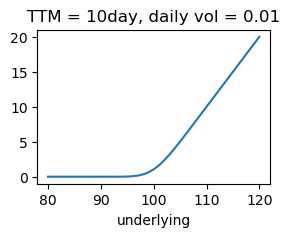

In [2]:
df = pd.DataFrame({
    "strike":[100] * 41, #[98, 99, 100, 101, 102]
    "underlying": np.arange(80,121).tolist()
    }) 
df["ttm"] = 10/360
df["r"] = 0
df["sigma"] = 0.01
# df["call_price"] = df
df["call_price"] = df.apply(lambda x: BlackScholesOracle.call_price(torch.tensor(x["underlying"]), torch.tensor(x["strike"]), x["ttm"], x["r"], x["sigma"]).item(), axis=1)
df.set_index("underlying")["call_price"].plot( figsize= (3,2), title= "TTM = 10day, daily vol = 0.01")

In [3]:
# delta should be approximately 0.5

delta = ( BlackScholesOracle.call_price(
   *[torch.tensor(x) for x in  [100.5, 100, 10/252, 0, 0.01]] ) 
    -
BlackScholesOracle.call_price(
   *[torch.tensor(x) for x in  [99.5, 100, 10/252, 0, 0.01]] ) 
)  
delta

tensor(0.5062)

In [ ]:

cfg = dict(
    S0=100.0, K=100.0, T=10.0/252.0, D =5, sigma=0.01, kappa=0.1, cost_multiplier=1.0, tick_size=0.1
)

# rl.Config.action_space = [-10.0, -5.0, 0.0, 5.0, 10.0] # Need to be modified, but I think this is not the main problem

env = OptionReplicationEnv(
    **cfg
)
agent = model(state_dim = 4, hidden_dim =64)
optimizer = optim.Adam(agent.parameters(), lr= 0.0001)
loss_log = []

# for epoch in range(150):
for epoch in range(3000):
    history = []
    print("epoch", epoch)

    # NUM_EPISODES = 3000
    NUM_EPISODES = 1000

    # ==========================================
    # 1. Simulating the environment to gather Data
    # ==========================================
    for _ in range(NUM_EPISODES):
        state = env.reset()
        done = False
        while not done:
            action = agent.get_action(state, epsilon=0.1)
            next_state, reward, done = env.step(action)
            
            # IMPORTANT: Save 'next_state' and 'done' into history
            # we use float() for reward and done to ensure they are python floats, not tensors
            history.append((state, action, float(reward), next_state, float(done)))
            state = next_state
            
    # ==========================================
    # 2. Ensemble Sampling (Batch Training)
    # ==========================================
    # Sample 10% from the collected trajectories
    sample_size = 128 

    if len(history) >= sample_size and sample_size > 0:
        for step in range( 5 * len(history) // sample_size ):
            # 1. Sample exactly `sample_size` transitions (breaks correlation)
            batch = random.sample(history, sample_size)
            
            # 2. Unpack the batch into separated lists using `zip(*batch)`
            states, actions, rewards, next_states, dones = zip(*batch)
            
            # 3. Stack lists into batched PyTorch Tensors
            states_t      = torch.stack(states)                            # Shape: [sample_size, 4]
            actions_t     = torch.tensor(actions, dtype=torch.long)        # Shape: [sample_size]
            rewards_t     = torch.tensor(rewards, dtype=torch.float32)     # Shape: [sample_size]
            next_states_t = torch.stack(next_states)                       # Shape: [sample_size, 4]
            dones_t       = torch.tensor(dones, dtype=torch.float32)       # Shape: [sample_size]
            
            # 4. Perform a SINGLE batched forward pass and loss calculation
            # FIXME batch size is too large. Is it a standard implemenation?
            loss = agent.td_loss(states_t, actions_t, rewards_t, next_states_t, dones_t)
            
            # 5. Backprop step
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(agent.parameters(), 1.0) # gradient clipping
            optimizer.step()
        print(f"Trained on {sample_size} samples . Loss: {loss.item():.4f}")
        loss_log.append(loss.item())
        print(f"Collected total {len(history)} transitions.")

epoch 0


In [ ]:
import matplotlib.pyplot as plt 
pd.Series(loss_log).plot(logy=True)

TypeError: no numeric data to plot

,underlying,position,action,reward,underlying_,u_ret,cum_ret
0,97.025581,-936.0,-63,-383.473555,-297.441864,NaN,-383.473555
1,97.881981,-999.0,39,0.049991,-211.801910,0.856400,-383.423564
2,97.865776,-960.0,-63,-9.339661,-213.422394,-0.016205,-392.763225
3,100.000000,0.0,-63,-5.402348,0.000000,2.134224,-398.165573
4,100.722778,-63.0,-27,0.049303,72.277832,0.722778,-398.116269
5,100.633255,-90.0,-63,-1.587246,63.325500,-0.089523,-399.703516
6,100.812820,-153.0,-89,-9.842333,81.282043,0.179565,-409.545848
7,101.189674,-242.0,-63,-28.769219,118.967438,0.376854,-438.315067
8,100.482628,-305.0,-63,-3.643566,48.262787,-0.707047,-441.958633
9,100.639893,-368.0,-63,-6.551683,63.989258,0.157265,-448.510316


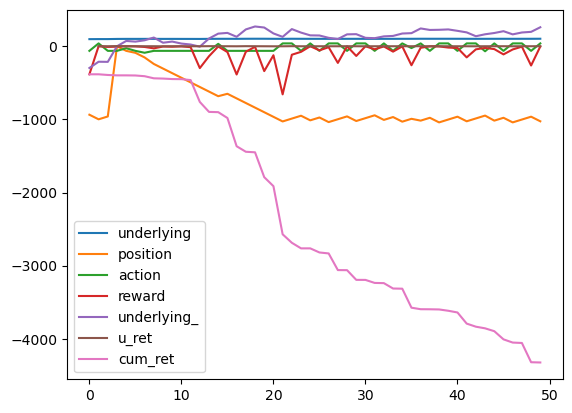

In [ ]:
ss = []
ps = []
aa = []
rs = []
for state, action, reward, _, _ in history: # state, action, float(reward), next_state, float(done)
    underlying, _, pos, _ = state.tolist()
    ss.append(underlying)
    ps.append(pos)
    aa.append(action)
    rs.append(reward)

import matplotlib.pyplot as plt 
# n = 1 * 50
n = len(ss) - 50
df = pd.DataFrame({
    "underlying": ss[n:n+50],
    "position" : ps[n:n+50], 
    "action": aa[n:n+50], 
    "reward": rs[n:n+50] 
})
df["underlying_"] =  (df["underlying"] - 100) * 100
df["u_ret"] = df["underlying"].diff()
df["reward"] /= 100
df["cum_ret"] = df["reward"].cumsum() 
df["action"] -= 100
# df["underlying"].plot()
df.plot()
df

<Axes: title={'center': 'Daily price change distributionstd = 0.01'}, ylabel='Frequency'>

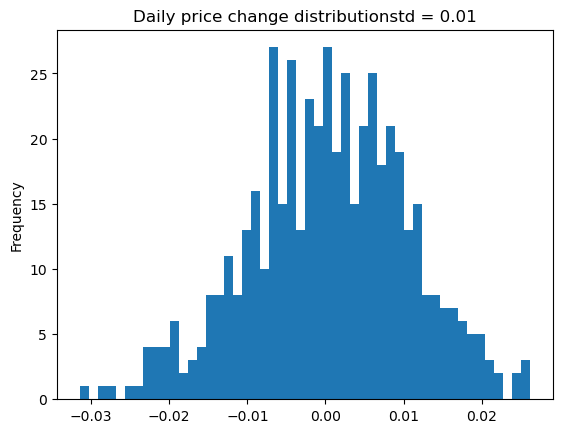

In [ ]:
import pandas as pd 
df_ret = pd.Series(ss).pct_change(5)
df_ret.clip(-0.1,0.1).plot.hist(bins=50, title="Daily price change distribution" + f"std = {df_ret.std().round(3)}")

In [7]:

cfg = dict(
    S0=100.0, K=100.0, T=10.0/252.0, D =5, sigma=0.01, kappa=0.1, cost_multiplier=1.0, tick_size=0.1
)

# rl.Config.action_space = [-10.0, -5.0, 0.0, 5.0, 10.0] # Need to be modified, but I think this is not the main problem

env = OptionReplicationEnv(
    **cfg
)
agent = model(state_dim = 4, hidden_dim =64)
optimizer = optim.Adam(agent.parameters(), lr= 0.0001)
loss_log = []

for epoch in range(150):
# for epoch in range(30):
    history = []
    print("epoch", epoch)

    # NUM_EPISODES = 3000
    NUM_EPISODES = 100

    # ==========================================
    # 1. Simulating the environment to gather Data
    # ==========================================
    for _ in range(NUM_EPISODES):
        state = env.reset()
        done = False
        while not done:
            action = agent.get_action(state, epsilon=0.1)
            next_state, reward, done = env.step(action)
            
            # IMPORTANT: Save 'next_state' and 'done' into history
            # we use float() for reward and done to ensure they are python floats, not tensors
            history.append((state, action, float(reward), next_state, float(done)))
            state = next_state
            
    # ==========================================
    # 2. Ensemble Sampling (Batch Training)
    # ==========================================
    # Sample 10% from the collected trajectories
    sample_size = 128 

    if len(history) >= sample_size and sample_size > 0:
        for step in range( len(history) // sample_size ):
            # 1. Sample exactly `sample_size` transitions (breaks correlation)
            batch = random.sample(history, sample_size)
            
            # 2. Unpack the batch into separated lists using `zip(*batch)`
            states, actions, rewards, next_states, dones = zip(*batch)
            
            # 3. Stack lists into batched PyTorch Tensors
            states_t      = torch.stack(states)                            # Shape: [sample_size, 4]
            actions_t     = torch.tensor(actions, dtype=torch.long)        # Shape: [sample_size]
            rewards_t     = torch.tensor(rewards, dtype=torch.float32)     # Shape: [sample_size]
            next_states_t = torch.stack(next_states)                       # Shape: [sample_size, 4]
            dones_t       = torch.tensor(dones, dtype=torch.float32)       # Shape: [sample_size]
            
            # 4. Perform a SINGLE batched forward pass and loss calculation
            # FIXME batch size is too large. Is it a standard implemenation?
            loss = agent.td_loss(states_t, actions_t, rewards_t, next_states_t, dones_t)
            
            # 5. Backprop step
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(agent.parameters(), 1.0) # gradient clipping
            optimizer.step()
            print(f"Trained on {sample_size} samples (10%). Loss: {loss.item():.4f}")
            loss_log.append(loss.item())
        print(f"Collected total {len(history)} transitions.")

epoch 0
Trained on 128 samples (10%). Loss: 10000.4189
Trained on 128 samples (10%). Loss: 4434.1831
Trained on 128 samples (10%). Loss: 1294.9382
Trained on 128 samples (10%). Loss: 3587.3833
Trained on 128 samples (10%). Loss: 1812.6259
Trained on 128 samples (10%). Loss: 1578.8597
Trained on 128 samples (10%). Loss: 1563.4916
Trained on 128 samples (10%). Loss: 1328.4359
Trained on 128 samples (10%). Loss: 527.6119
Trained on 128 samples (10%). Loss: 910.3094
Trained on 128 samples (10%). Loss: 551.6304
Trained on 128 samples (10%). Loss: 854.5488
Trained on 128 samples (10%). Loss: 1171.3950
Trained on 128 samples (10%). Loss: 532.1526
Trained on 128 samples (10%). Loss: 798.2735
Trained on 128 samples (10%). Loss: 566.6938
Trained on 128 samples (10%). Loss: 725.5044
Trained on 128 samples (10%). Loss: 781.8693
Trained on 128 samples (10%). Loss: 607.7003
Trained on 128 samples (10%). Loss: 600.3774
Trained on 128 samples (10%). Loss: 393.1127
Trained on 128 samples (10%). Loss: 3

KeyboardInterrupt: 

<Axes: >

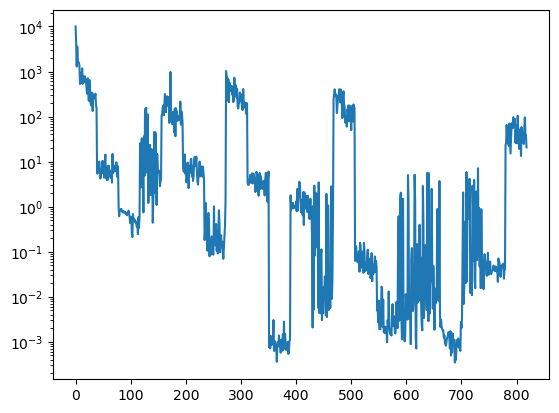

In [8]:
import matplotlib.pyplot as plt 
pd.Series(loss_log).plot(logy=True)

,underlying,position,action,reward,underlying_,u_ret,cum_ret
0,101.414230,326.0,-26,-9.570989,141.423035,NaN,-9.570989
1,100.000000,0.0,57,-0.150947,0.000000,-1.414230,-9.721936
2,99.712036,57.0,57,0.035907,-28.796387,-0.287964,-9.686029
3,100.066719,114.0,57,-2.521669,6.671906,0.354683,-12.207698
4,99.625008,171.0,57,-0.895587,-37.499237,-0.441711,-13.103285
5,99.964500,228.0,57,-6.038054,-3.549957,0.339493,-19.141339
6,99.574059,285.0,57,-61.985874,-42.594147,-0.390442,-81.127213
7,98.474548,342.0,-26,-10.380645,-152.545166,-1.099510,-91.507858
8,99.029617,316.0,-26,-0.646410,-97.038269,0.555069,-92.154267
9,98.929604,290.0,57,-15.805369,-107.039642,-0.100014,-107.959636


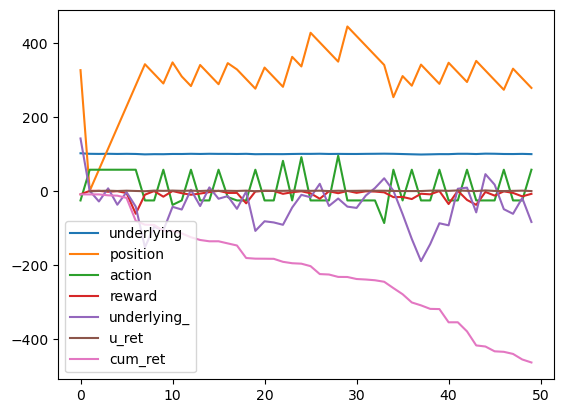

In [12]:
ss = []
ps = []
aa = []
rs = []
for state, action, reward, _, _ in history: # state, action, float(reward), next_state, float(done)
    underlying, _, pos, _ = state.tolist()
    ss.append(underlying)
    ps.append(pos)
    aa.append(action)
    rs.append(reward)

import matplotlib.pyplot as plt 
n = 1 * 50
# n = len(ss) -50
df = pd.DataFrame({
    "underlying": ss[n:n+50],
    "position" : ps[n:n+50], 
    "action": aa[n:n+50], 
    "reward": rs[n:n+50] 
})
df["underlying_"] =  (df["underlying"] - 100) * 100
df["u_ret"] = df["underlying"].diff()
df["reward"] /= 100
df["cum_ret"] = df["reward"].cumsum() 
df["action"] -= 100
# df["underlying"].plot()
df.plot()
df

<Axes: >

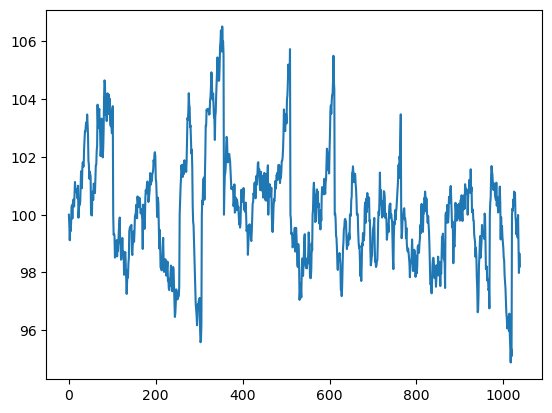

In [20]:

df = pd.DataFrame({
    "underlying": ss,
    "position"  : ps, 
    "action" :    aa, 
    "reward":     rs 
})
df["underlying"].plot()#.hist()